In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
df = pd.read_csv("phishing.csv")
df.head()
# this dataset represent the websites that are will Legitimate(represent as 1) or phishing (represent as -1)

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [31]:
df.describe()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,...,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000
mean,5526.500000,0.313914,-0.633345,0.738737,0.700561,0.741632,-0.734938,0.064049,0.251040,-0.336711,...,0.613353,0.816899,0.061335,0.377239,0.287407,-0.483626,0.721549,0.343948,0.719739,0.113986
std,3191.159272,0.949495,0.765973,0.674024,0.713625,0.670837,0.678165,0.817492,0.911856,0.941651,...,0.789845,0.576807,0.998162,0.926158,0.827680,0.875314,0.692395,0.569936,0.694276,0.993527
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2763.250000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5526.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8289.750000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11053.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
df.shape

(11054, 32)

In [33]:
df.isnull().sum()

,0
Index,0
UsingIP,0
LongURL,0
ShortURL,0
Symbol@,0
Redirecting//,0
PrefixSuffix-,0
SubDomains,0
HTTPS,0
DomainRegLen,0


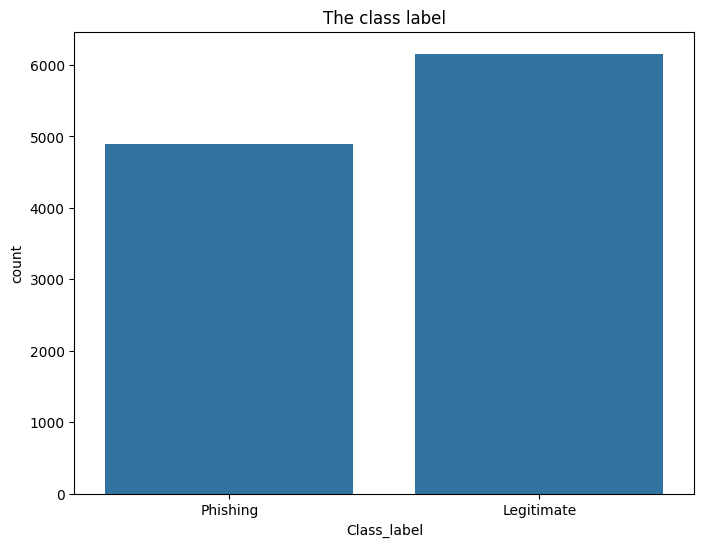

In [34]:
# what is the target variable of this dataset ?
df["Class_label"] = df["class"].map({1: "Legitimate", -1: "Phishing"})
plt.figure(figsize=(8,6))
sns.countplot(x="Class_label", data=df)
plt.title("The class label")
plt.show()
# insigh : the class is balance the number of Legitimate and Phishing are to close from each other

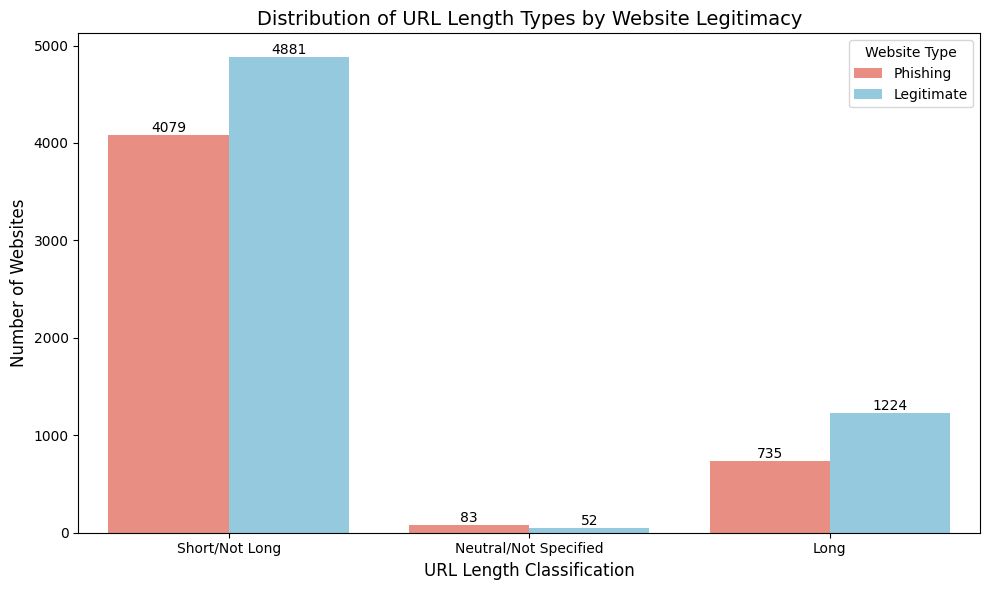

In [35]:
# Does fishing website use the long URL or slort URL?
longurl_mapping = {1: 'Long', 0: 'Neutral/Not Specified', -1: 'Short/Not Long'}
df['LongURL_Type'] = df['LongURL'].map(longurl_mapping)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x="LongURL_Type", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['Short/Not Long', 'Neutral/Not Specified', 'Long'])
plt.title("Distribution of URL Length Types by Website Legitimacy", fontsize=14)
plt.xlabel("URL Length Classification", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

#insigh : Phishing websites often use very short URLs (4079 websites)

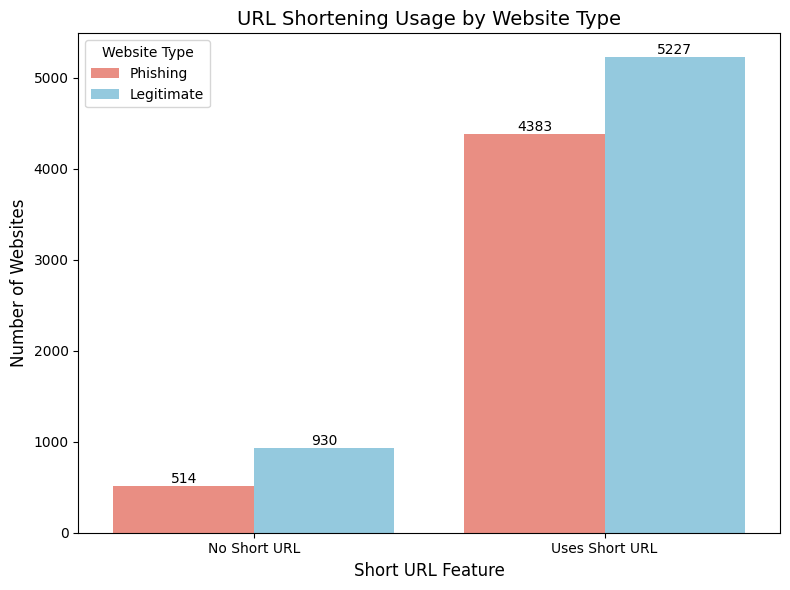

In [36]:
# what about the Short URL and what is the most uses the short URL?
shorturl_mapping = {1: 'Uses Short URL', -1: 'No Short URL'}
df['ShortURL_Type'] = df['ShortURL'].map(shorturl_mapping)
plt.figure(figsize=(8,6))
ax = sns.countplot(x="ShortURL_Type", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['No Short URL', 'Uses Short URL'])
plt.title("URL Shortening Usage by Website Type", fontsize=14)
plt.xlabel("Short URL Feature", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()
# insigh : the legitimate is the most usage the short URL
# why we have many phishing website here ?
# Phishing sites may hide the real domain using shortened URLs

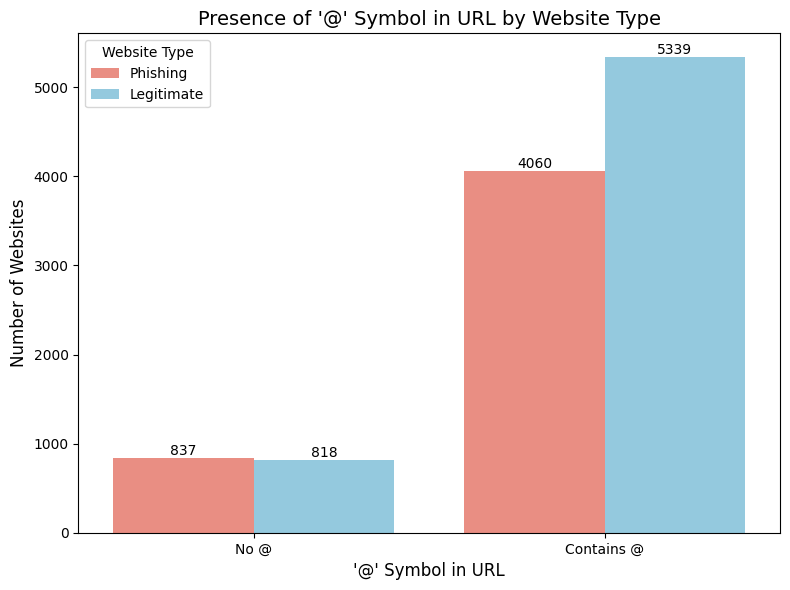

In [37]:
# what the website that contain the @ sympol ?
symbol_mapping = {1: 'Contains @', -1: 'No @'}
df['Symbol_Presence'] = df['Symbol@'].map(symbol_mapping)
plt.figure(figsize=(8,6))
ax = sns.countplot(x="Symbol_Presence", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['No @', 'Contains @'])
plt.title("Presence of '@' Symbol in URL by Website Type", fontsize=14)
plt.xlabel("'@' Symbol in URL", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()
# we have three insighs here :
# The @ symbol is extremely rare overall ,The vast majority of websites, both legitimate and phishing, do not contain the @ symbol
# Phishing sites are disproportionately more likely to use the @ symbol (example:http://real-site.com@phishing-site.com)
# If a URL contains @, the probability that it is a phishing site is much higher than if it does not

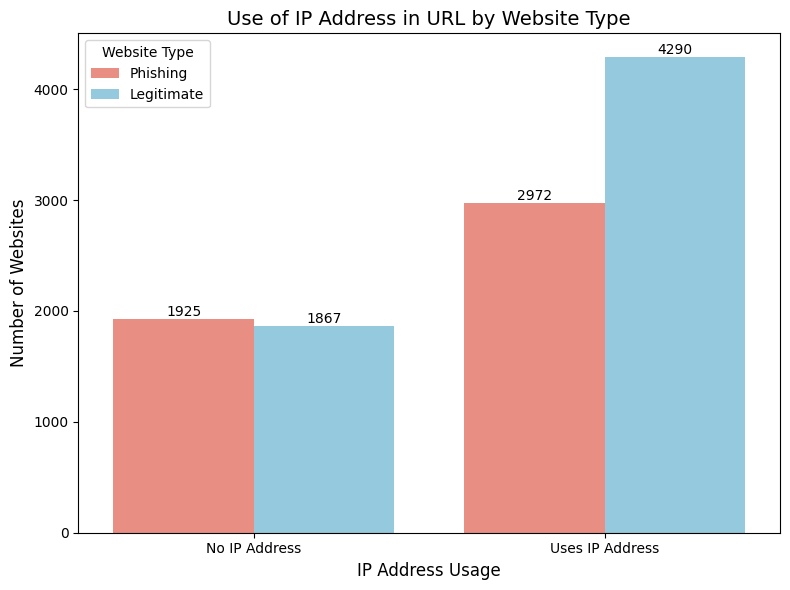

In [38]:
# Whether the URL uses an IP address instead of a domain name ?
usingip_mapping = {1: 'Uses IP Address', -1: 'No IP Address'}
df['UsingIP_Type'] = df['UsingIP'].map(usingip_mapping)
plt.figure(figsize=(8,6))
ax = sns.countplot(x="UsingIP_Type", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['No IP Address', 'Uses IP Address'])
plt.title("Use of IP Address in URL by Website Type", fontsize=14)
plt.xlabel("IP Address Usage", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()
#IP address usage is rare but revealing, The vast majority of websites do not use an IP address in their URL—they rely on normal domain names
#the counts of phishing (1,925) and legitimate (1,867) sites are nearly balanced, indicating that the absence of an IP address is not itself a strong differentiator
#IP addresses strongly signal phishing

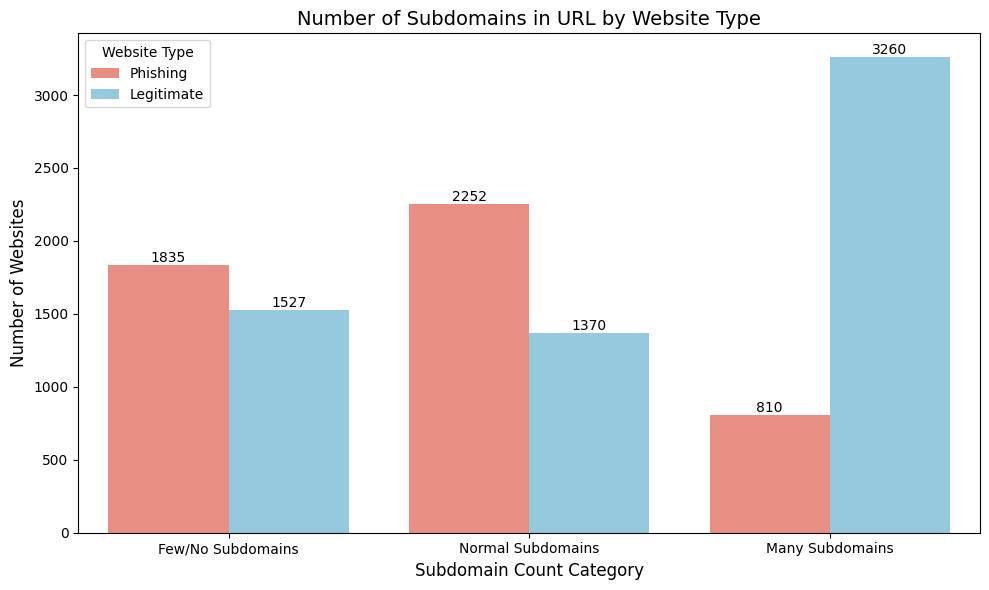

In [39]:
# waht the number of subdomains in the URL ?
subdomain_mapping = {-1: 'Few/No Subdomains', 0: 'Normal Subdomains', 1: 'Many Subdomains'}
df['SubDomains_Type'] = df['SubDomains'].map(subdomain_mapping)
plt.figure(figsize=(10,6))

ax = sns.countplot(x="SubDomains_Type", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['Few/No Subdomains', 'Normal Subdomains', 'Many Subdomains'])
plt.title("Number of Subdomains in URL by Website Type", fontsize=14)
plt.xlabel("Subdomain Count Category", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()
# Phishing sites heavily rely on normal or no subdomains

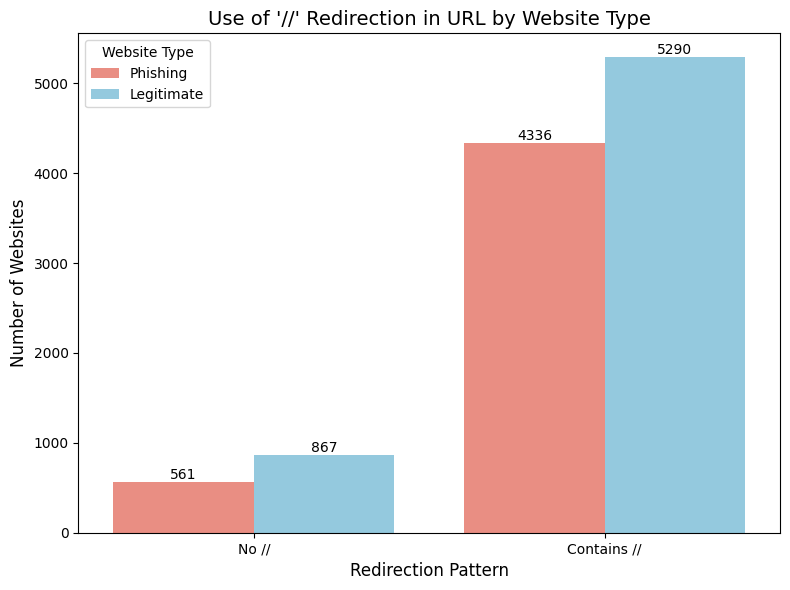


Percentage of phishing sites with '//': 88.54%


In [40]:
# how many website that use the Redirecting// ?
redirect_mapping = {1: 'Contains //', -1: 'No //'}
df['Redirecting_Type'] = df['Redirecting//'].map(redirect_mapping)
plt.figure(figsize=(8,6))
ax = sns.countplot(x="Redirecting_Type", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['No //', 'Contains //'])
plt.title("Use of '//' Redirection in URL by Website Type", fontsize=14)
plt.xlabel("Redirection Pattern", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()
# we have 9626 websites that have // (include the phishing website)
# what a precentage of phishing website that contain // ?
print("="*100)
print()
total_phishing = df[df['Class_label'] == 'Phishing'].shape[0]
phishing_with_redirect = df[(df['Class_label'] == 'Phishing') & (df['Redirecting//'] == 1)].shape[0]
percentage_phishing = (phishing_with_redirect / total_phishing) * 100
print(f"Percentage of phishing sites with '//': {percentage_phishing:.2f}%")

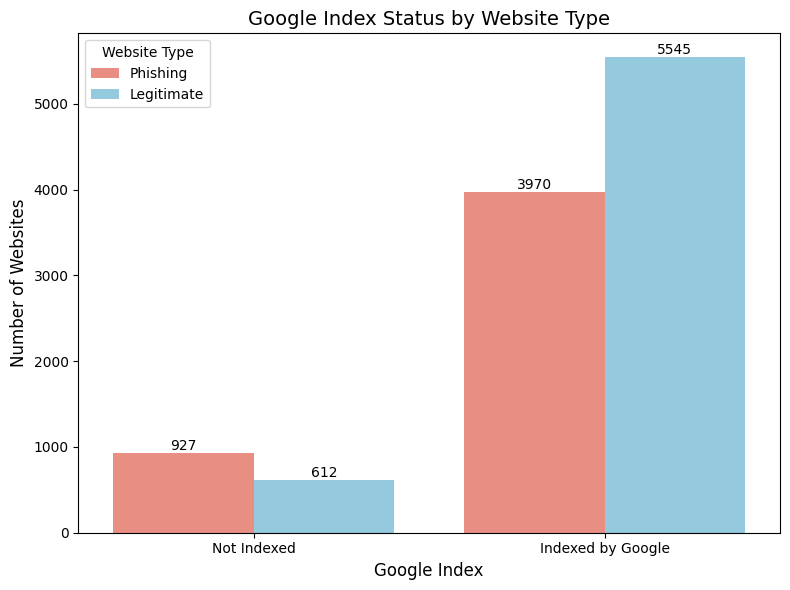

In [41]:
# what is the Percentage of phishing sites with GoogleInde?
google_mapping = {1: 'Indexed by Google', -1: 'Not Indexed'}
df['GoogleIndex_Status'] = df['GoogleIndex'].map(google_mapping)
plt.figure(figsize=(8,6))
ax = sns.countplot(x="GoogleIndex_Status", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['Not Indexed', 'Indexed by Google'])
plt.title("Google Index Status by Website Type", fontsize=14)
plt.xlabel("Google Index", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)
plt.legend(title='Website Type')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()
# 81.07% of phishing websites indexed by google
# we have 5545 Legitimate websites indexed by Google

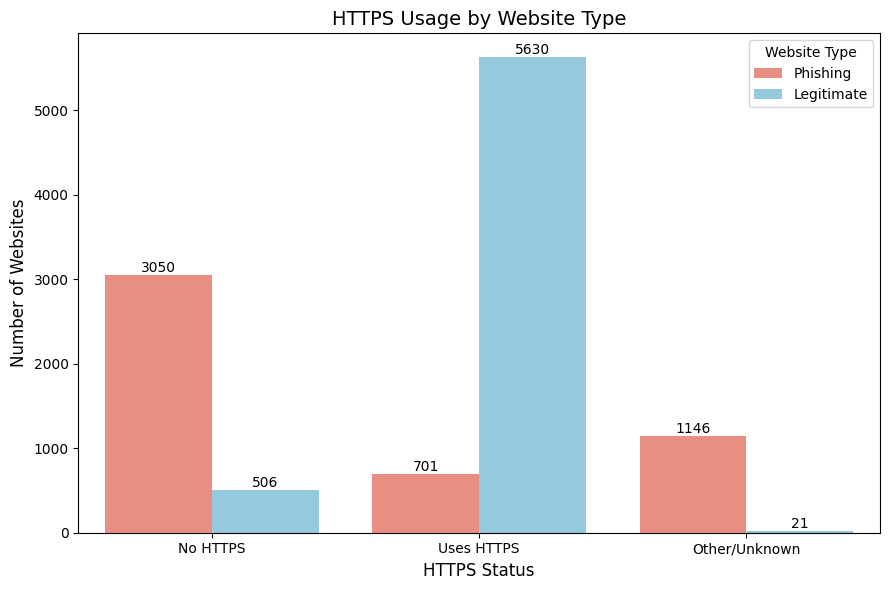


Total phishing websites: 4897
Phishing websites without HTTPS: 3050
Percentage: 62.28%


In [42]:
# what the number pf phishing websites that use the HTTPS ?
https_mapping = {1: 'Uses HTTPS', -1: 'No HTTPS', 0: 'Other/Unknown'}
df['HTTPS_Type'] = df['HTTPS'].map(https_mapping)

# --- Create the plot ---
plt.figure(figsize=(9,6))

# Countplot with mapped categories, hue by class, and logical order
ax = sns.countplot(x="HTTPS_Type", hue="Class_label", data=df,
                   palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
                   order=['No HTTPS', 'Uses HTTPS', 'Other/Unknown'])  # Logical order

# Titles and labels
plt.title("HTTPS Usage by Website Type", fontsize=14)
plt.xlabel("HTTPS Status", fontsize=12)
plt.ylabel("Number of Websites", fontsize=12)

# Legend
plt.legend(title='Website Type')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()
# many of phishing uses the HTTP not Use the HTTPS
# what the precentage of phishing website that not use the HTTPS
print("="*100)
print()
total_phishing = df[df['class'] == -1].shape[0]
phishing_no_https = df[(df['class'] == -1) & (df['HTTPS'] == -1)].shape[0]
percentage_phishing_no_https = (phishing_no_https / total_phishing) * 100

print(f"Total phishing websites: {total_phishing}")
print(f"Phishing websites without HTTPS: {phishing_no_https}")
print(f"Percentage: {percentage_phishing_no_https:.2f}%")
# the answer of our question is 62.28%

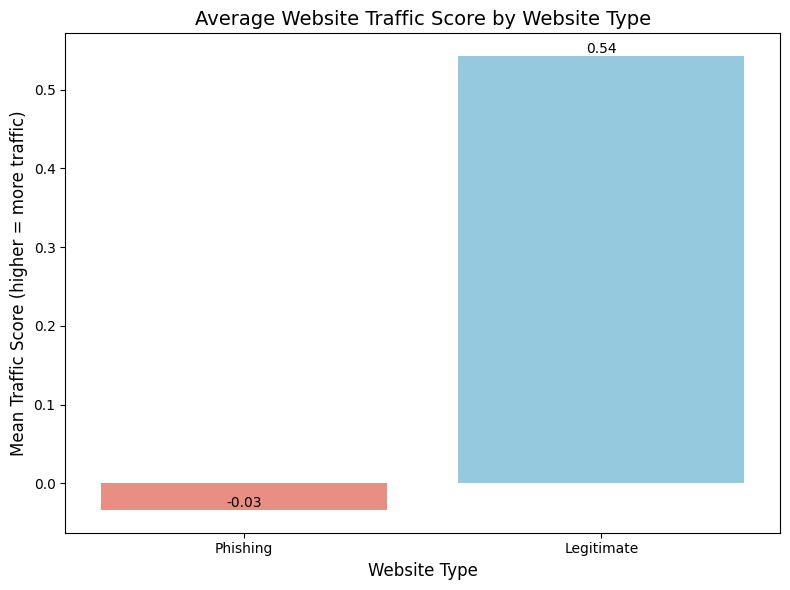

In [43]:

# what is the websites that have a high Traffic ?
plt.figure(figsize=(8,6))
ax = sns.barplot(
    x="Class_label",
    y="WebsiteTraffic",
    data=df,
    hue="Class_label",
    palette={'Legitimate': 'skyblue', 'Phishing': 'salmon'},
    errorbar=None,
    legend=False,
    estimator=np.mean
)
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom')

plt.title("Average Website Traffic Score by Website Type", fontsize=14)
plt.xlabel("Website Type", fontsize=12)
plt.ylabel("Mean Traffic Score (higher = more traffic)", fontsize=12)
plt.tight_layout()
plt.show()
# Legitimate Traffic is too high (higher = more efficient)
# Phishing sites usually have very low traffic.

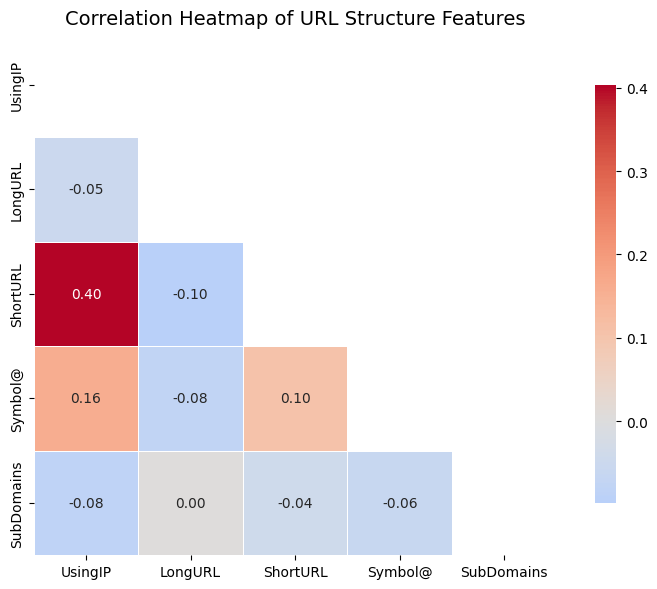

In [44]:
# what the correlation between UsingIP,LongURL,ShortURL,Symbol@,SubDomains
url_features = ['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'SubDomains']
corr_matrix = df[url_features].corr()
plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap of URL Structure Features", fontsize=14)
plt.tight_layout()
plt.show()

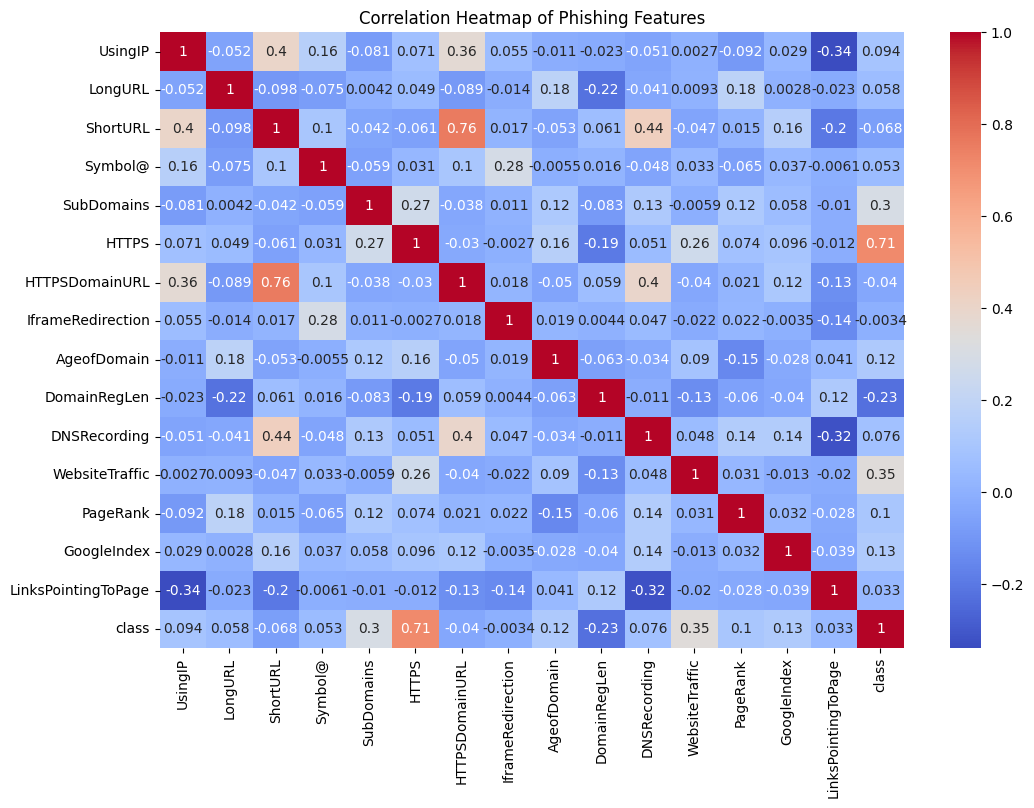


Top 5 features correlated with 'class':
HTTPS: 0.715
WebsiteTraffic: 0.346
SubDomains: 0.298
DomainRegLen: -0.226
GoogleIndex: 0.129

Top 10 strongest feature-feature correlations:
ShortURL – HTTPSDomainURL: 0.758
HTTPS – class: 0.715
ShortURL – DNSRecording: 0.436
UsingIP – ShortURL: 0.404
HTTPSDomainURL – DNSRecording: 0.395
UsingIP – HTTPSDomainURL: 0.363
WebsiteTraffic – class: 0.346
UsingIP – LinksPointingToPage: 0.339
DNSRecording – LinksPointingToPage: 0.318
SubDomains – class: 0.298


In [45]:
# what a coeerlation for some coluumns ?
cols = [
"UsingIP","LongURL","ShortURL","Symbol@","SubDomains",
"HTTPS","HTTPSDomainURL","IframeRedirection",
"AgeofDomain","DomainRegLen","DNSRecording",
"WebsiteTraffic","PageRank","GoogleIndex","LinksPointingToPage",
"class"
]

plt.figure(figsize=(12,8))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Phishing Features")
plt.show()
# what is the highest correlation of this heatmap ?
print("="*100)
print()
corr_matrix = df[cols].corr()
target_corr = corr_matrix['class'].drop('class')
top_target_corr = target_corr.abs().sort_values(ascending=False).head(5)
print("Top 5 features correlated with 'class':")
for feat, corr_val in target_corr[top_target_corr.index].items():
    print(f"{feat}: {corr_val:.3f}")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr_pairs = (upper_tri.stack()
                  .abs()
                  .sort_values(ascending=False)
                  .head(10))
print("\nTop 10 strongest feature-feature correlations:")
for (feat1, feat2), corr_val in top_corr_pairs.items():
    print(f"{feat1} – {feat2}: {corr_val:.3f}")
# with correlation with class , the highiest is HTTPS = 0.715
# the trongest feature-feature correlations is ShortURL – HTTPSDomainURL: 0.758
#

/tmp/ipykernel_346/2402674050.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


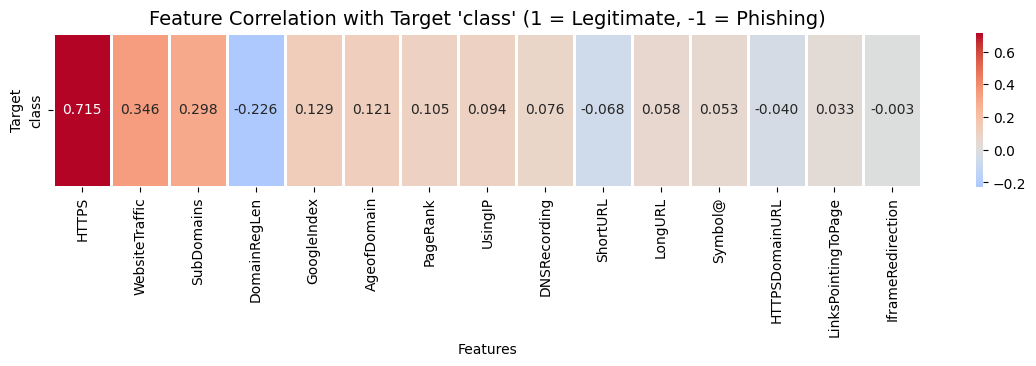

In [46]:
#what is the correlation with class ?
corr_with_class = df[cols].corr()['class'].drop('class').to_frame().T
sorted_features = corr_with_class.abs().sort_values(by=corr_with_class.index[0], axis=1, ascending=False).columns
corr_with_class_sorted = corr_with_class[sorted_features]

plt.figure(figsize=(14, 2))
sns.heatmap(corr_with_class_sorted,
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            center=0,
            cbar_kws={'orientation': 'vertical'},
            linewidths=1)
plt.title("Feature Correlation with Target 'class' (1 = Legitimate, -1 = Phishing)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Target")
plt.tight_layout()
plt.show()
# the red colors represent the Positive correlation while blue represent Negative correlation = phishing

ML part


Accuracy: 0.9687924016282226
              precision    recall  f1-score   support

          -1       0.97      0.96      0.96       979
           1       0.96      0.98      0.97      1232

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



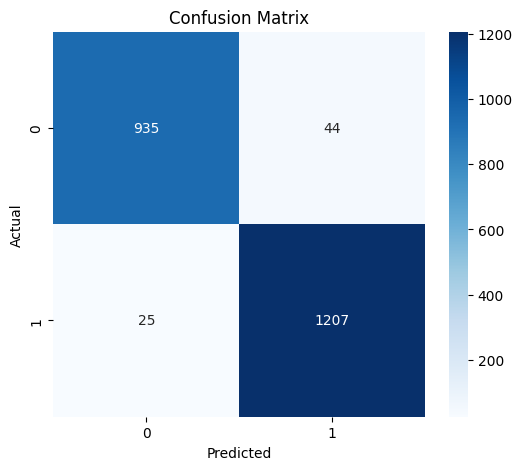

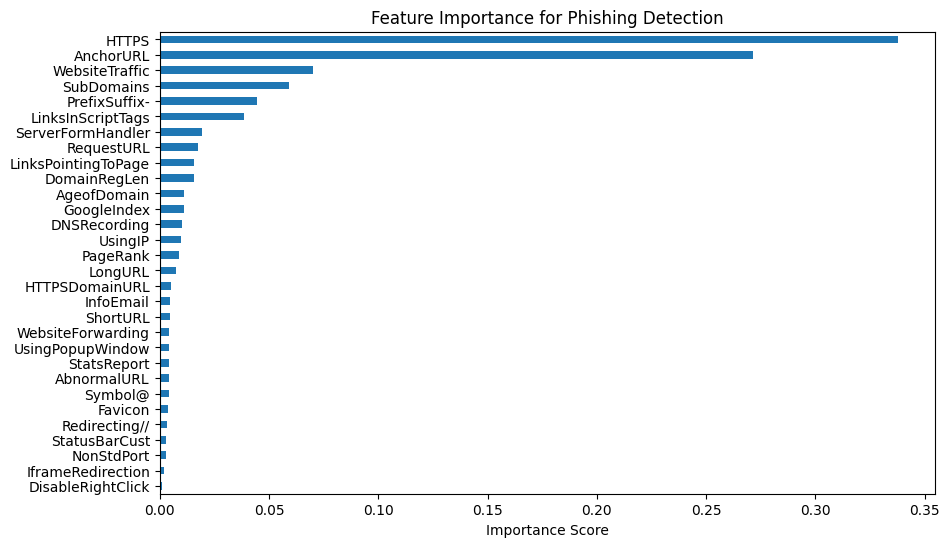

In [49]:
# I use the Random Forest model because a single Decision Tree can easily overfit ,Random Forest solves this by using many trees.
original_features = [
    'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
    'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
    'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
    'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
    'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
    'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain',
    'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex',
    'LinksPointingToPage', 'StatsReport'
]

X = df[original_features]   # This ensures only numeric codes are used
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
rf_model = RandomForestClassifier(n_estimators=300,max_depth=15,min_samples_split=5,random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Feature importance ( important for Cybersecurity)
feature_importance = pd.Series(rf_model.feature_importances_,index=X.columns)
feature_importance.sort_values(ascending=True).plot(kind="barh",figsize=(10,6))
plt.title("Feature Importance for Phishing Detection")
plt.xlabel("Importance Score")
plt.show()
# Random Forest model achieves 97% accuracy with nearly identical precision and recall for both classes,
# This means it correctly identifies 96% of phishing sites while maintaining 98% recall for legitimate sites.